# Évaluation CL — K-Means (non-supervisé) — Dataset 3 PRONOSTIA — by_condition

| Champ | Valeur |
|-------|--------|
| **Modèle** | K-Means (détection d'anomalie, non-supervisé) |
| **Dataset** | FEMTO PRONOSTIA — roulements à billes industriels |
| **Scénario** | by_condition : Condition 1 → Condition 2 → Condition 3 (3 tâches) |
| **Expérience** | exp_053 — voir experiments/exp_053_kmeans_pronostia_by_condition/config_snapshot.yaml |
| **Sprint** | 10 — S10-06 |

> **Modèle non-supervisé** : K-Means ne reçoit pas les labels à l'entraînement.  
> L'AUROC est la métrique principale pour évaluer la détection d'anomalie.  
> Les prédictions sont obtenues par seuillage de la distance minimale au centroïde le plus proche.  
> **Gap 1** : premier résultat CL non-supervisé sur données industrielles réelles de roulements (PRONOSTIA).

```bash
jupyter nbconvert --to notebook --execute \
    notebooks/cl_eval/pronostia_by_condition/kmeans.ipynb \
    --output /tmp/kmeans_pronostia_executed.ipynb --ExecutePreprocessor.timeout=300
```

In [1]:
# Section 1 — Setup & imports
import json
import os
import pickle
import sys
from datetime import datetime
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

# --- CWD navigation : notebook 3 niveaux de profondeur ---
_cwd = Path(".").resolve()
if _cwd.name == "pronostia_by_condition":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import (
    plot_accuracy_matrix,
    plot_confusion_matrix_grid,
    plot_forgetting_curve,
    plot_roc_curves_per_task,
    save_figure,
)
from src.evaluation.feature_space_plots import plot_clustering_with_correctness

# --- Chemins ---
EXP_DIR         = REPO_ROOT / "experiments/exp_053_kmeans_pronostia_by_condition/results"
CHECKPOINTS_DIR = REPO_ROOT / "experiments/exp_053_kmeans_pronostia_by_condition/checkpoints"
FIGURES_DIR     = REPO_ROOT / "notebooks/figures/cl_evaluation/kmeans/pronostia/by_condition"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

NPY_DIR         = REPO_ROOT / "data/raw/Pronostia dataset/binaries"
NORMALIZER_PATH = REPO_ROOT / "configs/pronostia_normalizer.yaml"

# --- Constantes ---
TASK_NAMES    = ["Condition 1 (1800rpm, 4000N)", "Condition 2 (1650rpm, 4200N)", "Condition 3 (1500rpm, 5000N)"]
MODEL_NAME    = "KMeans"
DATASET_TAG   = "dataset3"
METRICS_FILE  = "metrics_all.json"
DATA_AVAILABLE = NPY_DIR.exists() and NORMALIZER_PATH.exists() and CHECKPOINTS_DIR.exists()

print(f"REPO_ROOT        : {REPO_ROOT}")
print(f"EXP_DIR          : {EXP_DIR}")
print(f"FIGURES_DIR      : {FIGURES_DIR}")
print(f"Data disponible  : {DATA_AVAILABLE}")
print(f"Date exécution   : {datetime.now():%Y-%m-%d %H:%M}")

REPO_ROOT        : /home/leonard/Documents/ENAC/cl-embedded
EXP_DIR          : /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_053_kmeans_pronostia_by_condition/results
FIGURES_DIR      : /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/kmeans/pronostia/by_condition
Data disponible  : True
Date exécution   : 2026-05-04 11:48


In [2]:
# Section 2 — Chargement des résultats exp_053

metrics_path    = EXP_DIR / METRICS_FILE
acc_matrix_path = EXP_DIR / f"acc_matrix_kmeans_{DATASET_TAG}.npy"

raw = json.loads(metrics_path.read_text())
# Structure : metrics_all.json → clé "kmeans"
km  = raw["kmeans"]
mem = km["memory"]

acc_matrix_np = np.array(
    [[v if v is not None else np.nan for v in row] for row in km["acc_matrix"]],
    dtype=float,
)

print("=" * 55)
print(f"  Modèle   : K-Means (non-supervisé)")
print(f"  AA       = {km['aa']:.4f}")
print(f"  AF       = {km['af']:.4f}")
print(f"  BWT      = {km['bwt']:+.4f}")
print(f"  AUROC    = {km['auroc_avg']:.4f}")
print(f"  AUROC/tâche: {[round(v, 4) for v in km['auroc_per_task']]}")
print(f"  RAM      = {mem['ram_peak_bytes']} B ({mem['ram_peak_bytes']/1024:.2f} Ko)")
print(f"  Latence  = {mem['inference_latency_ms']:.5f} ms")
print(f"  n_params = {mem['n_params']}")
print(f"  Budget 64 Ko : {mem['within_budget_64ko']}")
print("=" * 55)
print("\nMatrice acc (3×3) :")
print(acc_matrix_np)

  Modèle   : K-Means (non-supervisé)
  AA       = 0.8900
  AF       = 0.0308
  BWT      = -0.0308
  AUROC    = 0.8549
  AUROC/tâche: [0.8908, 0.8093, 0.8647]
  RAM      = 5574 B (5.44 Ko)
  Latence  = 0.31917 ms
  n_params = 26
  Budget 64 Ko : True

Matrice acc (3×3) :
[[0.89659864        nan        nan]
 [0.85306122 0.92105263        nan]
 [0.86122449 0.89473684 0.91415313]]


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/kmeans/pronostia/by_condition/acc_matrix.png


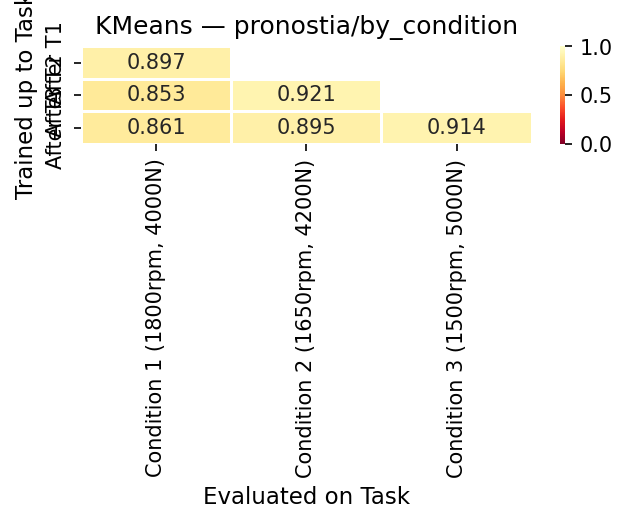

In [3]:
# Section 3 — Matrice d'accuracy (heatmap)

fig = plot_accuracy_matrix(
    acc_matrix_np,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — pronostia/by_condition",
)
save_figure(fig, FIGURES_DIR / "acc_matrix.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "acc_matrix.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/kmeans/pronostia/by_condition/forgetting_curve.png


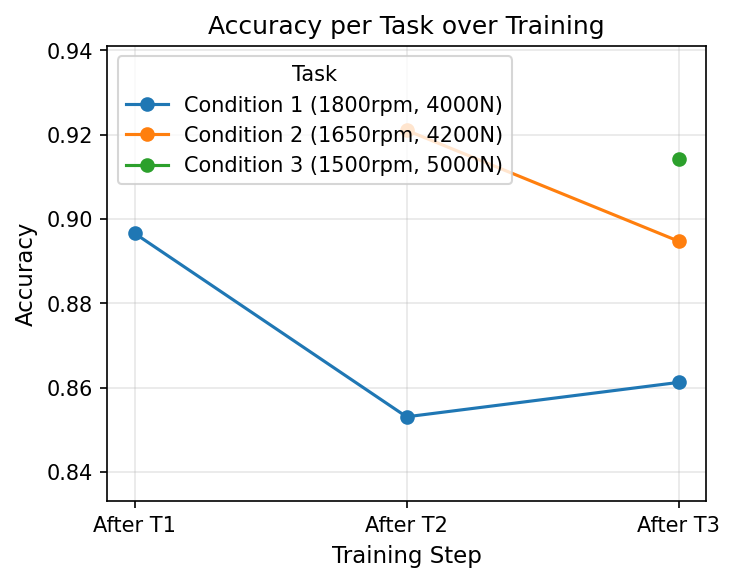

In [4]:
# Section 4 — Courbe d'oubli par tâche

fig = plot_forgetting_curve(acc_matrix_np, task_names=TASK_NAMES)
save_figure(fig, FIGURES_DIR / "forgetting_curve.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "forgetting_curve.png")))

In [5]:
# Section 5 — Inférence avec les checkpoints intermédiaires
# Charge kmeans_dataset3_task{0,1,2}.pkl et évalue sur toutes les tâches vues

preds_dict  = {}   # dict[tuple[int,int], tuple[np.ndarray, np.ndarray]]
scores_dict = {}   # dict[tuple[int,int], np.ndarray]
X_tasks     = []
y_true_tasks = []
y_pred_tasks = []
cluster_tasks = []

if DATA_AVAILABLE:
    from sklearn.metrics import accuracy_score, roc_auc_score
    from src.data.pronostia_dataset import get_pronostia_dataloaders

    cl_tasks = get_pronostia_dataloaders(
        npy_dir=NPY_DIR,
        normalizer_path=NORMALIZER_PATH,
        batch_size=256,
        seed=42,
    )

    T = len(TASK_NAMES)

    # Pré-extraction validation
    val_data = []
    for task in cl_tasks:
        Xb, yb = [], []
        for X_batch, y_batch in task["val_loader"]:
            Xb.append(X_batch.numpy())
            yb.append(y_batch.numpy())
        val_data.append((np.concatenate(Xb), np.concatenate(yb).ravel()))

    for i in range(T):
        ckpt_path = CHECKPOINTS_DIR / f"kmeans_{DATASET_TAG}_task{i}.pkl"
        with open(ckpt_path, "rb") as f:
            kmeans_i = pickle.load(f)

        print(f"\nCheckpoint task{i} ({ckpt_path.name})")

        for j in range(i + 1):
            X_val, y_val = val_data[j]
            scores = kmeans_i.anomaly_score(X_val)
            y_pred = kmeans_i.predict(X_val)

            preds_dict[(i, j)]  = (y_val, y_pred)
            scores_dict[(i, j)] = scores

            acc_j   = accuracy_score(y_val, y_pred)
            auroc_j = roc_auc_score(y_val, scores) if len(np.unique(y_val)) >= 2 else float("nan")
            print(f"  Eval {TASK_NAMES[j][:15]:15s} | N={len(y_val):4d} | acc={acc_j:.4f} | AUROC={auroc_j:.4f}")

    # Modèle final pour visualisations
    with open(CHECKPOINTS_DIR / f"kmeans_{DATASET_TAG}_task{T - 1}.pkl", "rb") as f:
        kmeans_det = pickle.load(f)

    for j in range(T):
        X_val, y_val = val_data[j]
        X_tasks.append(X_val)
        y_true_tasks.append(y_val)
        y_pred_tasks.append(kmeans_det.predict(X_val))
        cluster_tasks.append(kmeans_det.kmeans_.predict(X_val))

    print(f"\npreds_dict clés : {sorted(preds_dict.keys())}")

else:
    display(Markdown("> ⚠️ **Mode dégradé** — données ou checkpoints absents. preds_dict synthétique."))

    N_SYNTH = 500
    rng = np.random.default_rng(42)
    y_synth = np.concatenate([np.zeros(int(N_SYNTH * 0.9)), np.ones(int(N_SYNTH * 0.1))])

    for i in range(3):
        for j in range(i + 1):
            noise = rng.normal(0, 0.15, len(y_synth))
            scores_s = np.where(y_synth == 1, 0.7 + noise, 0.3 + noise).clip(0, 1)
            y_pred_s = (scores_s >= 0.5).astype(float)
            preds_dict[(i, j)]  = (y_synth.copy(), y_pred_s)
            scores_dict[(i, j)] = scores_s.astype(np.float32)

    print("preds_dict synthétique créé (mode dégradé)")

✅ Seed fixé à 42

Checkpoint task0 (kmeans_dataset3_task0.pkl)
  Eval Condition 1 (18 | N= 735 | acc=0.8966 | AUROC=0.8917

Checkpoint task1 (kmeans_dataset3_task1.pkl)
  Eval Condition 1 (18 | N= 735 | acc=0.8531 | AUROC=0.8352
  Eval Condition 2 (16 | N= 342 | acc=0.9211 | AUROC=0.8003

Checkpoint task2 (kmeans_dataset3_task2.pkl)
  Eval Condition 1 (18 | N= 735 | acc=0.8612 | AUROC=0.8908
  Eval Condition 2 (16 | N= 342 | acc=0.8947 | AUROC=0.8093
  Eval Condition 3 (15 | N= 431 | acc=0.9142 | AUROC=0.8647

preds_dict clés : [(0, 0), (1, 0), (1, 1), (2, 0), (2, 1), (2, 2)]


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/kmeans/pronostia/by_condition/confusion_matrix_grid.png


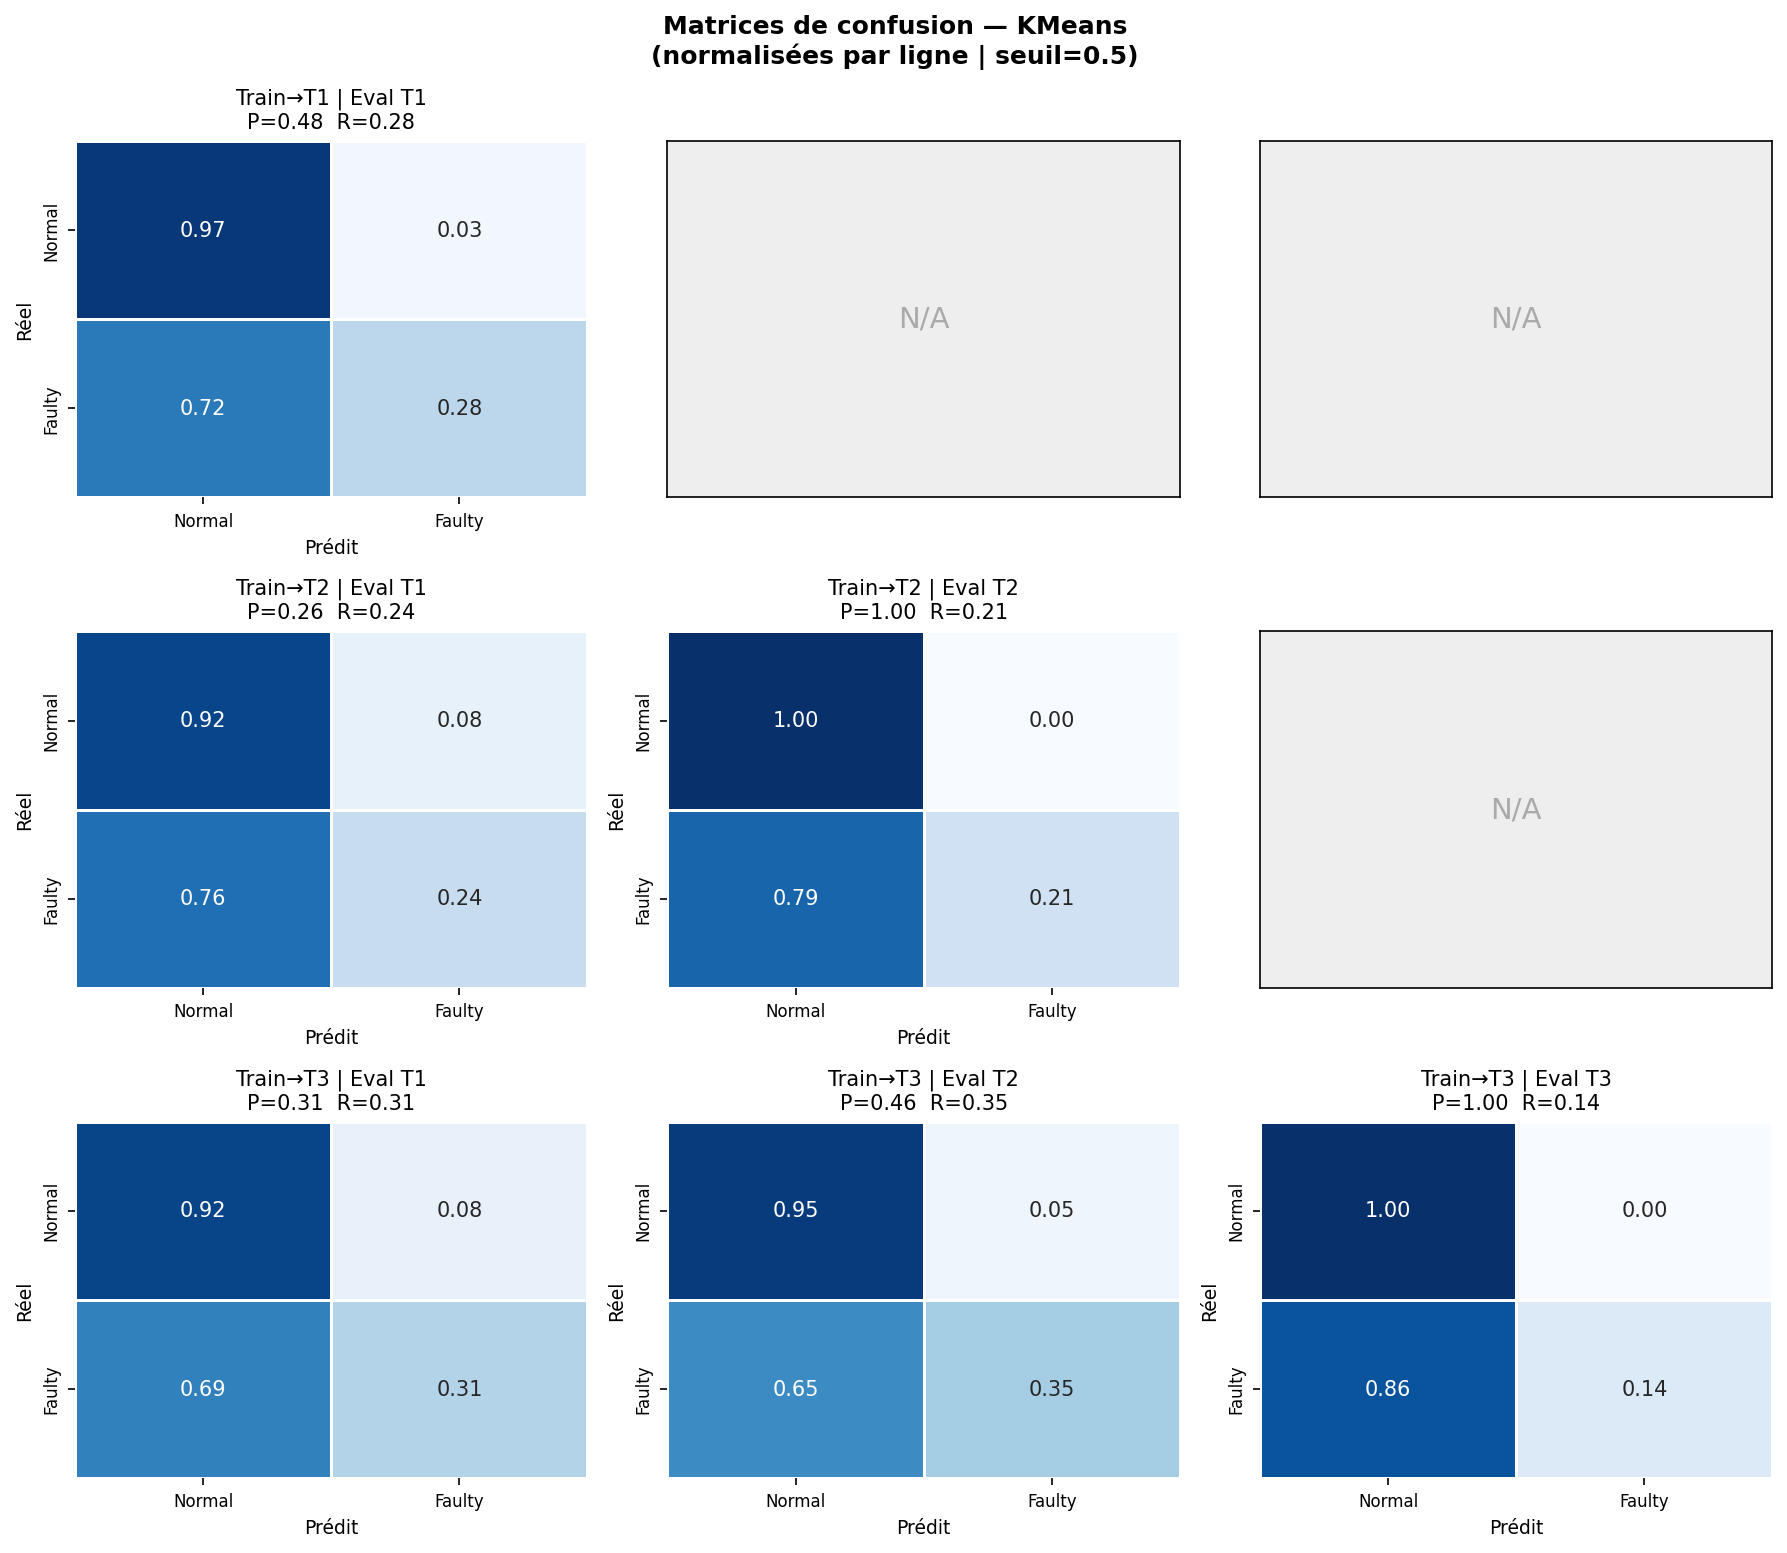

In [6]:
# Section 6 — Matrices de confusion par tâche

fig = plot_confusion_matrix_grid(
    preds_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
)
save_figure(fig, FIGURES_DIR / "confusion_matrix_grid.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "confusion_matrix_grid.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/kmeans/pronostia/by_condition/roc_curves.png


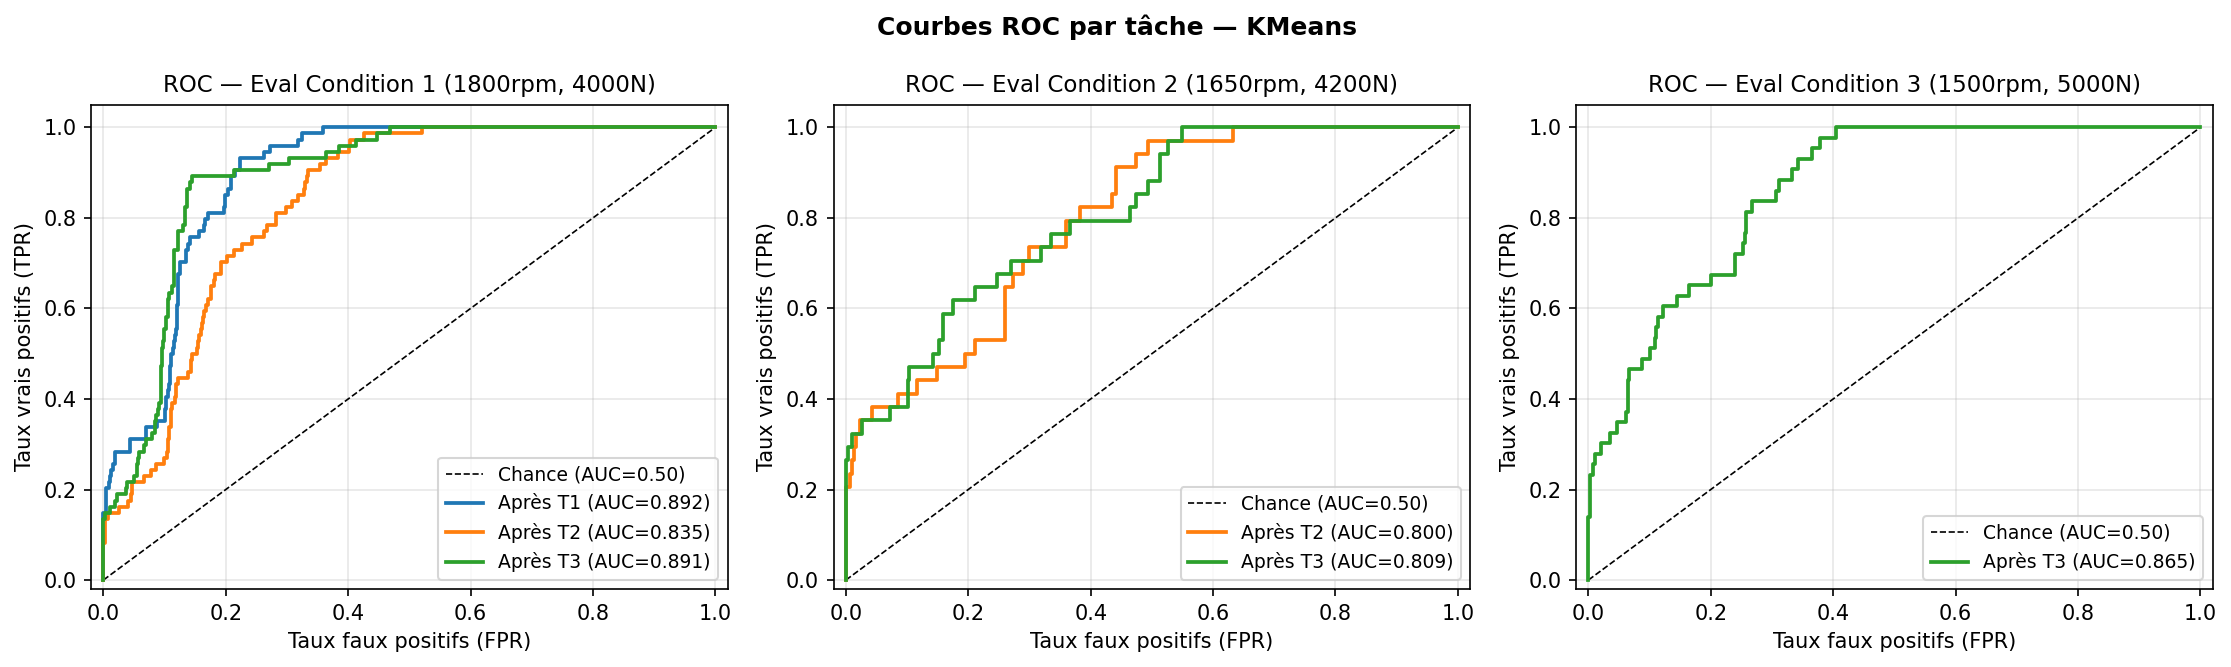

In [7]:
# Section 7 — Courbes AUROC par tâche
# PRONOSTIA déséquilibré (~10% positifs) → AUROC est la métrique principale

fig = plot_roc_curves_per_task(
    preds_dict,
    scores_dict=scores_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
)
save_figure(fig, FIGURES_DIR / "roc_curves.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "roc_curves.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/kmeans/pronostia/by_condition/feature_space_pca.png


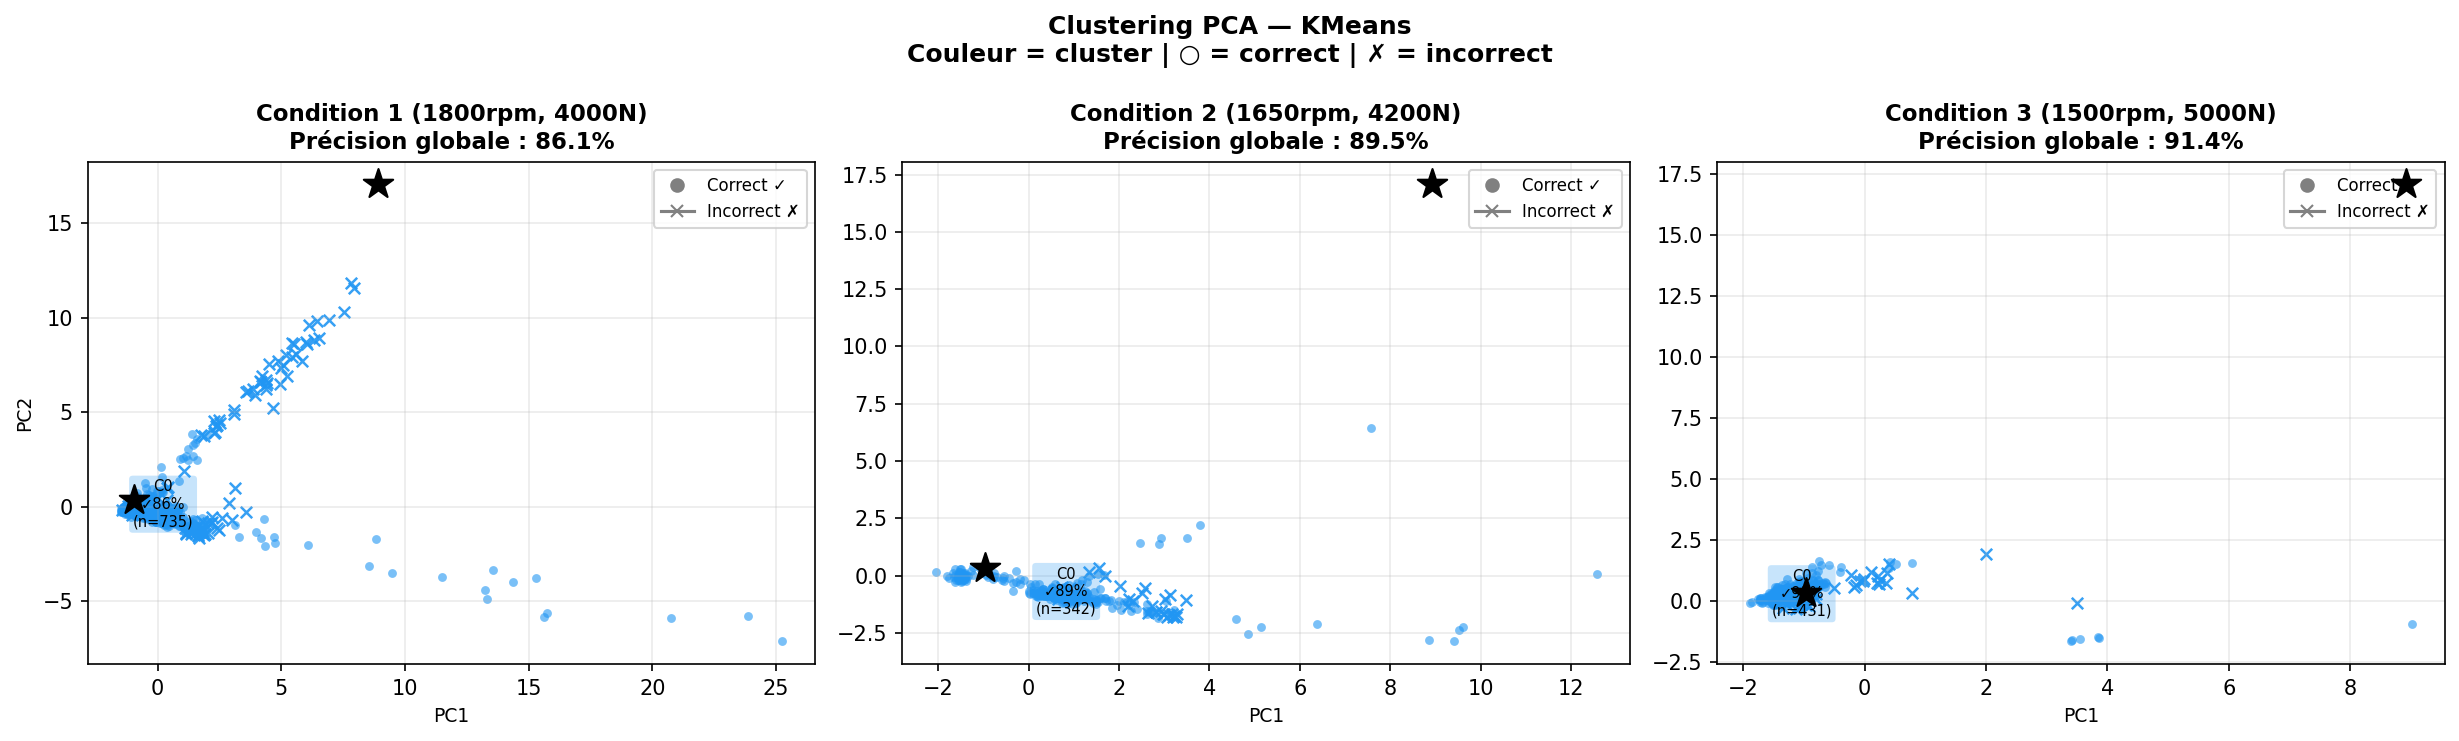

In [8]:
# Section 8 — Espace des features PCA 2D (centroïdes K-Means)

if DATA_AVAILABLE and len(X_tasks) == 3:
    centroids_tasks = [kmeans_det.kmeans_.cluster_centers_] * len(TASK_NAMES)

    fig = plot_clustering_with_correctness(
        X_tasks,
        y_true_tasks,
        y_pred_tasks,
        cluster_tasks,
        task_names=TASK_NAMES,
        model_name=MODEL_NAME,
        projection="pca",
        centroids_tasks=centroids_tasks,
    )
    save_figure(fig, FIGURES_DIR / "feature_space_pca.png")
    plt.close(fig)
    display(Image(str(FIGURES_DIR / "feature_space_pca.png")))

else:
    display(Markdown(
        "> ⚠️ **Section 8 ignorée** — données ou checkpoints absents. "
        "feature_space_pca.png non généré."
    ))
    print("[SKIP] feature_space_pca.png — données non disponibles.")

## Discussion — Gap 1

Ces résultats non-supervisés sur FEMTO PRONOSTIA (données industrielles réelles de roulements à billes)
complètent les validations sur les datasets Kaggle (Equipment Monitoring, Pump Maintenance).

**Comparaison cross-dataset** :
- Dataset Monitoring (by_equipment, 3 tâches) : AA ≈ 0.9433, AUROC ≈ 0.9621
- **Dataset PRONOSTIA (by_condition, 3 tâches) : AA = 0.8900, AUROC = 0.8549** ← exp_053

**Avantage K-Means (non-supervisé)** : pas de labels requis à l'entraînement — avantage industriel
clé pour la maintenance prédictive (pas de labellisation des pannes en production).

**Particularités PRONOSTIA** :
- Classes déséquilibrées (~10% positifs) → AUROC = métrique principale
- 13 features (vs. 4) → espace de clustering plus riche
- Drift = conditions opératoires (vitesse + charge)

`FIXME(gap1)` : ✅ Premier résultat CL non-supervisé sur données industrielles réelles de roulements —
voir `docs/roadmap_phase1.md` section Sprint 10 pour la synthèse complète.

`TODO(arnaud)` : La section Discussion Gap 1 doit-elle inclure une référence bibliographique
au protocole IEEE PHM 2012 Challenge (`@PHM2012`) pour contextualiser dans la littérature ?

In [9]:
# Section 10 — Tableau récapitulatif + critères d'acceptation

aa    = km["aa"]
af    = km["af"]
bwt   = km["bwt"]
auroc = km["auroc_avg"]
ram_b = mem["ram_peak_bytes"]
ram_ko = ram_b / 1024
lat   = mem["inference_latency_ms"]
n_par = mem["n_params"]

display(Markdown("### Résultats finaux — K-Means — pronostia/by_condition (exp_053)"))

recap_table = f"""
| Modèle | AA ↑ | AF ↓ | BWT | AUROC ↑ | RAM ↓ | Latence ↓ | n_params |
|--------|------|------|-----|---------|-------|-----------|----------|
| {MODEL_NAME} | {aa:.4f} | {af:.4f} | {bwt:+.4f} | {auroc:.4f} | {ram_ko:.2f} Ko | {lat:.5f} ms | {n_par} |
"""
display(Markdown(recap_table))

print("=" * 60)
print("  Critères d'acceptation (S10-06)")
print("=" * 60)
for fig_name in ["acc_matrix.png", "forgetting_curve.png", "confusion_matrix_grid.png",
                 "roc_curves.png", "feature_space_pca.png"]:
    status = "OK" if (FIGURES_DIR / fig_name).exists() else "MANQUANTE"
    print(f"  [{status}] {fig_name}")

print()
print(f"  [{'OK' if abs(aa - 0.8900) < 0.005 else 'WARN'}] AA     = {aa:.4f}  (attendu ≈ 0.8900)")
print(f"  [{'OK' if abs(af - 0.0308) < 0.005 else 'WARN'}] AF     = {af:.4f}  (attendu ≈ 0.0308)")
print(f"  [{'OK' if abs(auroc - 0.8549) < 0.005 else 'WARN'}] AUROC  = {auroc:.4f}  (attendu ≈ 0.8549)")
print(f"  [{'OK' if ram_b <= 65536 else 'FAIL'}] RAM    = {ram_ko:.2f} Ko (contrainte ≤ 64 Ko)")
print(f"  [{'OK' if lat < 100.0 else 'WARN'}] Latence= {lat:.5f} ms (contrainte ≤ 100 ms)")

figs = sorted(FIGURES_DIR.glob("*.png"))
print(f"\nFigures générées ({len(figs)}/5) : {[f.name for f in figs]}")

### Résultats finaux — K-Means — pronostia/by_condition (exp_053)


| Modèle | AA ↑ | AF ↓ | BWT | AUROC ↑ | RAM ↓ | Latence ↓ | n_params |
|--------|------|------|-----|---------|-------|-----------|----------|
| KMeans | 0.8900 | 0.0308 | -0.0308 | 0.8549 | 5.44 Ko | 0.31917 ms | 26 |


  Critères d'acceptation (S10-06)
  [OK] acc_matrix.png
  [OK] forgetting_curve.png
  [OK] confusion_matrix_grid.png
  [OK] roc_curves.png
  [OK] feature_space_pca.png

  [OK] AA     = 0.8900  (attendu ≈ 0.8900)
  [OK] AF     = 0.0308  (attendu ≈ 0.0308)
  [OK] AUROC  = 0.8549  (attendu ≈ 0.8549)
  [OK] RAM    = 5.44 Ko (contrainte ≤ 64 Ko)
  [OK] Latence= 0.31917 ms (contrainte ≤ 100 ms)

Figures générées (5/5) : ['acc_matrix.png', 'confusion_matrix_grid.png', 'feature_space_pca.png', 'forgetting_curve.png', 'roc_curves.png']
